In [1]:
FILENAME = "fullfile_ascii_3.csv"

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import GridSearchCV
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
import lime
import lime.lime_tabular
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from scipy.sparse import hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import lime
import lime.lime_text

/home/lucypher/Desktop/xAI/final project/.venv311/lib64/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv(FILENAME, low_memory=False)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1788003 entries, 0 to 1788002
Data columns (total 27 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Unnamed: 0                int64  
 1   backers_count             int64  
 2   blurb                     object 
 3   category                  object 
 4   converted_pledged_amount  float64
 5   country                   object 
 6   goal                      float64
 7   id                        int64  
 8   location                  object 
 9   name                      object 
 10  photo                     int64  
 11  pledged                   float64
 12  spotlight                 int64  
 13  staff_pick                int64  
 14  state                     int64  
 15  usd_pledged               float64
 16  video                     int64  
 17  prelaunch_activated       int64  
 18  is_liked                  int64  
 19  is_disliked               int64  
 20  is_starrable            

In [5]:
df['state'].value_counts()

1    1123662
0     664341
Name: state, dtype: int64

In [6]:
df['video'].value_counts()

1    1243983
0     544020
Name: video, dtype: int64

In [7]:
df['photo'].value_counts()

1    1787768
0        235
Name: photo, dtype: int64

In [8]:
df["blurb"] = df["blurb"].astype(str)

In [9]:
df = df.drop(columns=['Unnamed: 0','id','name','location', 'spotlight','converted_pledged_amount','usd_pledged'])

In [10]:
df_sampled = df.sample(n=10000, random_state=42).reset_index(drop=True)

In [11]:
df_sampled["state"].value_counts()

1    6261
0    3739
Name: state, dtype: int64

In [12]:
df.columns

Index(['backers_count', 'blurb', 'category', 'country', 'goal', 'photo',
       'pledged', 'staff_pick', 'state', 'video', 'prelaunch_activated',
       'is_liked', 'is_disliked', 'is_starrable', 'blurb_wc', 'dale_chall',
       'flesch_kincaid', 'smog', 'gun_fog', 'camp_len'],
      dtype='object')

In [13]:
X_blurb = df_sampled["blurb"]
y = df_sampled["state"]
X_other = df_sampled.drop(columns=["blurb", "state"])

In [14]:
X_other

,backers_count,category,country,goal,photo,pledged,staff_pick,video,prelaunch_activated,is_liked,is_disliked,is_starrable,blurb_wc,dale_chall,flesch_kincaid,smog,gun_fog,camp_len
0,30,Jewelry,CA,2200.0,1,3390.00,0,1,0,0,0,0,20,12.52,42.72,0.0,14.00,1
1,109,Anthologies,US,2156.0,1,2237.00,0,1,0,0,0,0,20,12.82,44.41,0.0,10.00,1
2,0,Wearables,US,10000.0,1,0.00,0,1,0,0,0,0,15,14.91,30.87,0.0,14.00,1
3,1,Comedy,NZ,7000.0,1,5.00,0,0,0,0,0,0,18,10.67,44.75,0.0,13.87,1
4,22,Illustration,US,500.0,1,1674.00,0,0,1,0,0,0,18,11.55,44.75,0.0,13.87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,26,Children's Books,US,880.0,1,1297.00,0,0,1,0,0,0,20,8.58,25.80,0.0,14.00,2
9996,26,Fiction,AU,786.0,1,996.32,0,1,1,0,0,0,20,11.07,47.75,10.5,12.68,1
9997,116,Gadgets,US,12500.0,1,14450.00,0,1,0,0,0,0,21,7.16,69.28,0.0,8.01,1
9998,0,Sculpture,FR,10000.0,1,0.00,0,0,0,0,0,0,16,18.25,63.70,0.0,11.40,1


In [15]:
tf_vector = TfidfVectorizer(ngram_range=(2, 2), \
                    stop_words='english', \
                    max_features=1000)  # remove stopwords and choose top 1000 features
tf_idf = tf_vector.fit_transform(X_blurb)

In [16]:
scores = []
for k in range(100, 1001, 100):
    sel = SelectKBest(score_func=chi2, k=k).fit(tf_idf, y)
    X_k = sel.transform(tf_idf)
    acc = cross_val_score(MultinomialNB(), X_k, y, cv=5).mean()
    scores.append((k, acc))

best_k, best_acc = max(scores, key=lambda x: x[1])
print(f"Best k: {best_k}, Accuracy: {best_acc:.3f}")

Best k: 400, Accuracy: 0.668


In [17]:
tf_vector = TfidfVectorizer(ngram_range=(2, 2), \
                    stop_words='english', \
                    max_features=400)  # remove stopwords and choose top 400 features (Best fit)
tf_idf = tf_vector.fit_transform(X_blurb)

In [18]:
# numeric = ["backers_count", "converted_pledged_amount", "goal", "pledged", "blurb_wc", "dale_chall", "flesch_kincaid", "smog", "gun_fog", "camp_len"]
print(X_other.select_dtypes(include=['object', 'category']).columns.tolist())
categorical = X_other.select_dtypes(include=['object', 'category']).columns.tolist()
numeric = X_other.select_dtypes(include=['int64', 'float64', 'bool']).columns.tolist()

['category', 'country']


In [19]:
other_text_cols = ['blurb_wc', 'dale_chall', 'flesch_kincaid', 'smog', 'gun_fog', 'camp_len']

In [20]:
transformer = ColumnTransformer([
        ('cat', OneHotEncoder(sparse_output=False), categorical),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric)
    ])

In [21]:
X_transformed = transformer.fit_transform(X_other)

In [22]:
X_text = hstack([tf_idf, X_other[other_text_cols]])
X_final = hstack([X_transformed, tf_idf])

In [23]:
onehot_feature_names = transformer.named_transformers_['cat'].get_feature_names_out()
numeric_features = transformer.transformers_[1][2]
tfidf_feature_names = tf_vector.get_feature_names_out()
all_feature_names = np.concatenate([onehot_feature_names, numeric_features, tfidf_feature_names])
X_dense = X_final.toarray()
X_df = pd.DataFrame(X_dense, columns=all_feature_names)
X_tfidf_df = pd.DataFrame(tf_idf.toarray(), columns=tf_vector.get_feature_names_out())
X_text_df = pd.concat([X_tfidf_df, X_other[other_text_cols]], axis=1)

In [24]:
X_df.head()

,category_3D Printing,category_Academic,category_Accessories,category_Action,category_Animals,category_Animation,category_Anthologies,category_Apparel,category_Apps,category_Architecture,...,year round,years ago,years making,years old,york city,young adult,young girl,young man,young people,young woman
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
X_train_text, X_test_text, y_train, y_test = train_test_split(X_text_df, y, test_size=0.2, stratify=y, random_state=42)
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_df, y, test_size=0.2, stratify=y, random_state=42)

In [26]:
model_text = XGBClassifier(eval_metric='logloss', 
                           scale_pos_weight=3,  # example, tune this
                           max_depth=6, 
                           learning_rate=0.1, 
                           reg_alpha=0.5, 
                           reg_lambda=1)


In [27]:
model_text.fit(X_train_text, y_train)

# Evaluate
y_pred_text = model_text.predict(X_test_text)
y_proba_text = model_text.predict_proba(X_test_text)[:, 1]

print("Text-only AUC:", roc_auc_score(y_test, y_proba_text))
print("Text-only F1:", f1_score(y_test, y_pred_text))

Text-only AUC: 0.623216756932224
Text-only F1: 0.7714728682170543


In [28]:
model_all = XGBClassifier(eval_metric='logloss', 
                          scale_pos_weight=3,  # tune!
                          max_depth=6, 
                          learning_rate=0.1, 
                          reg_alpha=0.5, 
                          reg_lambda=1)

model_all.fit(X_train_all, y_train_all)

# Evaluate
y_pred_all = model_all.predict(X_test_all)
y_proba_all = model_all.predict_proba(X_test_all)[:, 1]

print("All features AUC:", roc_auc_score(y_test_all, y_proba_all))
print("All features F1:", f1_score(y_test_all, y_pred_all))

All features AUC: 0.9999028292699594
All features F1: 0.9944400317712471


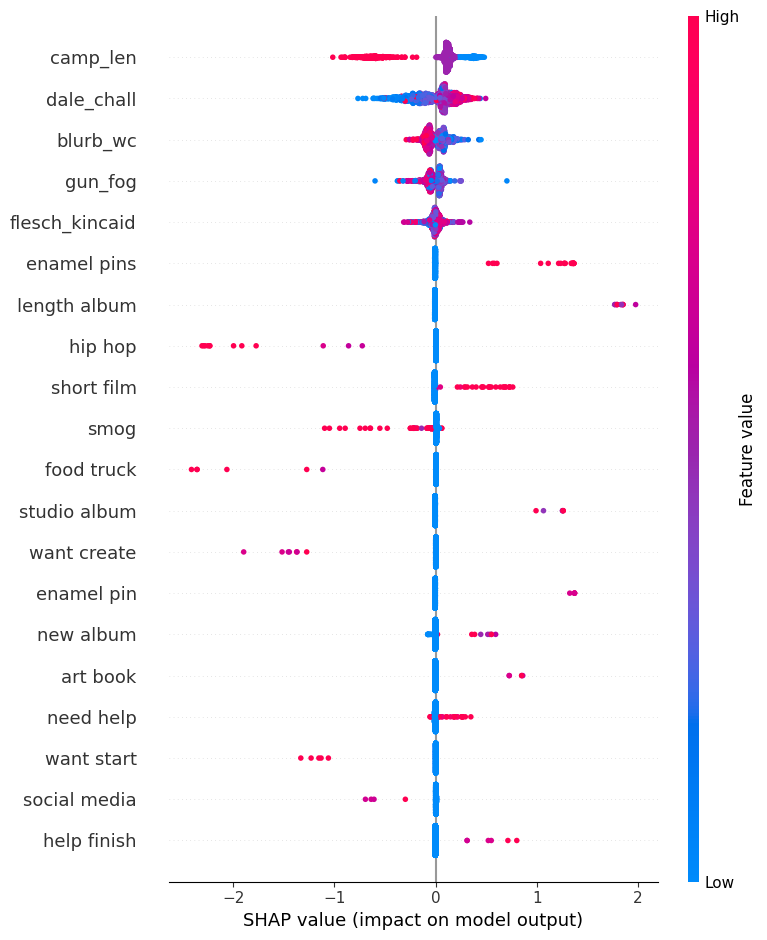

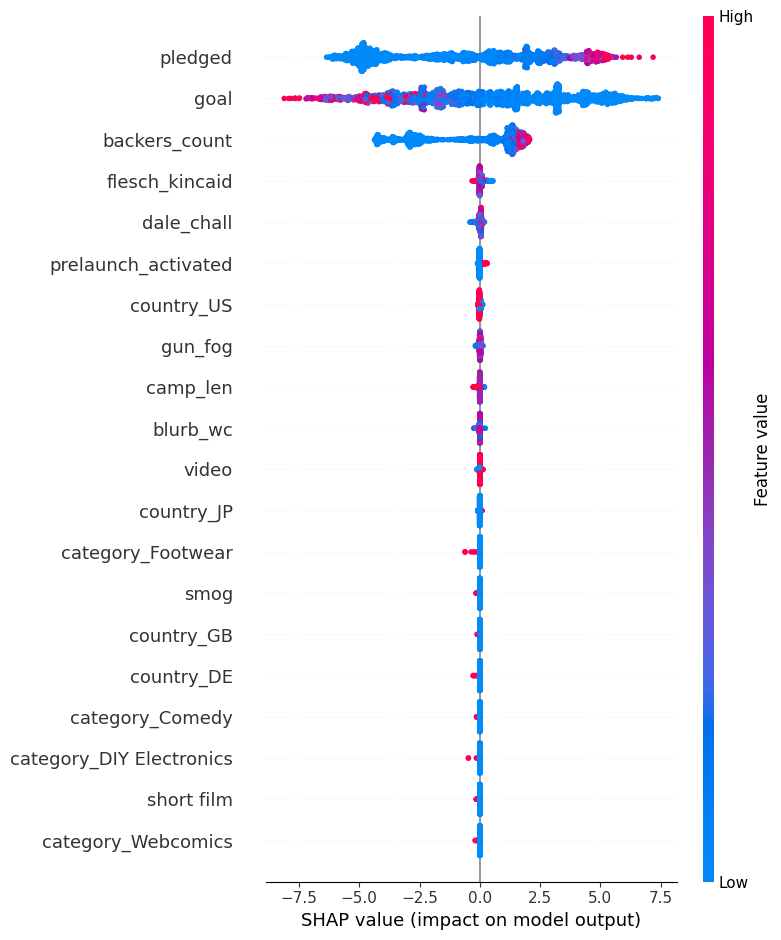

In [29]:
# Explain model 1 (text-only)
explainer_text = shap.TreeExplainer(model_text)
shap_values_text = explainer_text.shap_values(X_test_text)

shap.summary_plot(shap_values_text, X_test_text)

# Explain model 2 (all features)
explainer_all = shap.TreeExplainer(model_all)
shap_values_all = explainer_all.shap_values(X_test_all)

shap.summary_plot(shap_values_all, X_test_all)

In [30]:
params = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [1, 3, 5],
    'reg_alpha': [0.1, 0.5],
    'reg_lambda': [0.5, 1]
}

grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), 
                    param_grid=params, 
                    scoring='roc_auc', 
                    cv=3, 
                    verbose=1)

grid.fit(X_train_all, y_train)
print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'reg_alpha': 0.1, 'reg_lambda': 0.5, 'scale_pos_weight': 3}


In [31]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_text, y_train)
rf_pred = rf.predict(X_test_text)
rf_proba = rf.predict_proba(X_test_text)[:, 1]
print("RF AUC:", roc_auc_score(y_test, rf_proba))
print("RF F1:", f1_score(y_test, rf_pred))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_text, y_train)
lr_pred = lr.predict(X_test_text)
lr_proba = lr.predict_proba(X_test_text)[:, 1]
print("LR AUC:", roc_auc_score(y_test, lr_proba))
print("LR F1:", f1_score(y_test, lr_pred))


RF AUC: 0.6115482607507132
RF F1: 0.7048929663608563
LR AUC: 0.6416845346910184
LR F1: 0.759780370624571


In [32]:
# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_all, y_train)
rf_pred = rf.predict(X_test_all)
rf_proba = rf.predict_proba(X_test_all)[:, 1]
print("RF AUC:", roc_auc_score(y_test_all, rf_proba))
print("RF F1:", f1_score(y_test_all, rf_pred))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_all, y_train)
lr_pred = lr.predict(X_test_all)
lr_proba = lr.predict_proba(X_test_all)[:, 1]
print("LR AUC:", roc_auc_score(y_test_all, lr_proba))
print("LR F1:", f1_score(y_test_all, lr_pred))


RF AUC: 0.9936144948830534
RF F1: 0.9687255668491008
LR AUC: 0.9439741333652253
LR F1: 0.9000404694455686


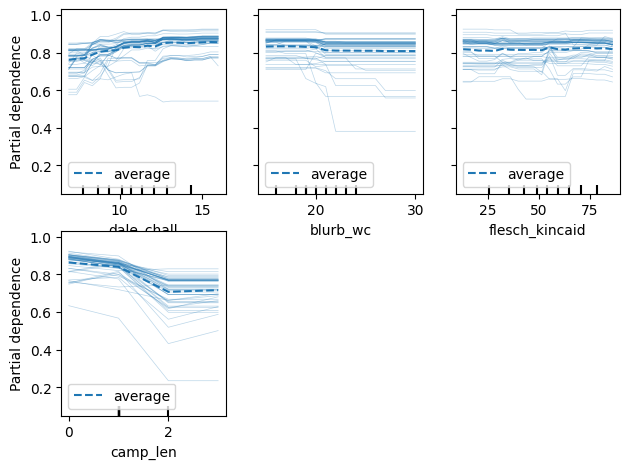

In [33]:
features=['dale_chall', 'blurb_wc', 'flesch_kincaid', 'camp_len']  # or ['goal']

# Plot PDP and ICE
PartialDependenceDisplay.from_estimator(
    model_text,
    X_test_text,
    features,
    kind="both",  # "average", "individual", or "both"
    subsample=50,  # ICE can be dense; subsample for clarity
    grid_resolution=20,
    random_state=0
)

plt.tight_layout()
plt.show()


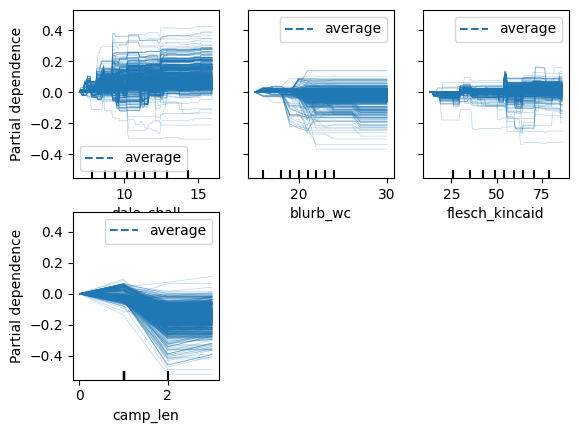

In [34]:
PartialDependenceDisplay.from_estimator(
    model_text,
    X_test_text,
    features=['dale_chall', 'blurb_wc', 'flesch_kincaid', 'camp_len'], 
    kind="both",
    centered=True
)

In [35]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_all),
    feature_names=X_train_all.columns.tolist(),
    # class_names=['failure', 'success'],
    categorical_features=categorical,
    discretize_continuous=True,
    mode='classification'
)

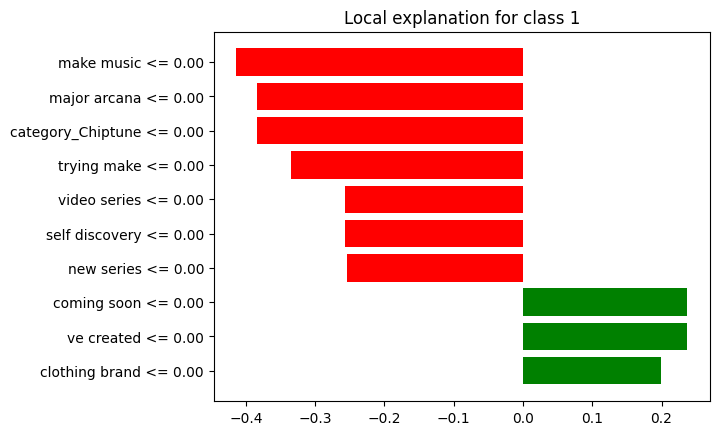

In [36]:
idx = 250
instance = X_test_all.iloc[idx].values

# Explain the prediction
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=model_all.predict_proba
)
print(exp)
# Show results



exp.show_in_notebook()


%matplotlib inline
fig = exp.as_pyplot_figure()

In [37]:


exp.save_to_file('oi.html')


In [38]:
import dice_ml
from dice_ml import Dice
from dice_ml.utils import helpers

In [39]:
train_df = pd.concat([X_train_all, y_train], axis=1)

In [40]:
train_df["target"] = train_df["state"]
train_df = train_df.drop(columns="state")

In [43]:
# Define your metadata
d = dice_ml.Data(
    dataframe=train_df,  # includes features + target
    continuous_features=numeric,  # list your numeric columns
    categorical_features=categorical,  # list your categorical ones
    outcome_name='target'
)

# Wrap the model
m = dice_ml.Model(model=model_all, backend='sklearn')  # or 'xgboost' if you're using raw xgboost API


In [44]:
exp2 = Dice(d, m, method="random")  # "random" is simplest; you can also try "genetic"


In [48]:
query_instance = X_test_all.iloc[0].to_dict()  # Pick any instance to explain
query_instance_df = pd.DataFrame([query_instance])

In [49]:
dice_exp = exp2.generate_counterfactuals(
    query_instance_df,
    total_CFs=3,
    desired_class="opposite"
)


  0%|                                                                                                                                                 | 0/1 [00:00<?, ?it/s]


ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:category_3D Printing: object, category_Academic: object, category_Accessories: object, category_Action: object, category_Animals: object, category_Animation: object, category_Anthologies: object, category_Apps: object, category_Architecture: object, category_Art: object, category_Art Books: object, category_Audio: object, category_Bacon: object, category_Blues: object, category_Calendars: object, category_Camera Equipment: object, category_Ceramics: object, category_Children's Books: object, category_Childrenswear: object, category_Chiptune: object, category_Civic Design: object, category_Classical Music: object, category_Comedy: object, category_Comic Books: object, category_Community Gardens: object, category_Conceptual Art: object, category_Cookbooks: object, category_Country & Fo

In [ ]:
dice_exp.visualize_as_dataframe()
